In [103]:
import numpy as np

def euclidean_distance(a, b):
    # Euclidean distance between two vectors
    return np.linalg.norm(a - b)
from sklearn.cluster import KMeans

def mean_clusters(data_matrix, cluster_assignments, n_clusters):
    import numpy as np
    cluster_assignments = cluster_assignments.astype(int)  # ensure integer indices
    
    # Sum of points per cluster
    sums = np.zeros((n_clusters, data_matrix.shape[1]))
    np.add.at(sums, cluster_assignments, data_matrix)
    
    # Count of points per cluster
    counts = np.bincount(cluster_assignments, minlength=n_clusters).reshape(-1, 1)
    
    # Mean = sums / counts (safe division)
    mean_cluster = np.divide(sums, counts, where=counts > 0)
    return mean_cluster


def variance_clusters(data_matrix, cluster_assignments, n_clusters):
    import numpy as np
    # Compute cluster means first
    mean_cluster = mean_clusters(data_matrix, cluster_assignments, n_clusters)
    
    # Sum of squared deviations per cluster
    sq_dev = np.zeros((n_clusters, data_matrix.shape[1]))
    np.add.at(sq_dev, cluster_assignments, (data_matrix - mean_cluster[cluster_assignments])**2)
    
    # Count of points per cluster
    counts = np.bincount(cluster_assignments, minlength=n_clusters).reshape(-1, 1)
    
    # Variance = sum of squared deviations / count
    variance_cluster = np.divide(sq_dev, counts, where=counts>0)
    return variance_cluster

def plot_clusters(data_matrix, cluster_assignments, centroids):
    import matplotlib.pyplot as plt
    
    # Define feature pairs to plot (x_index, y_index, x_label, y_label)
    feature_pairs = [
        (0, 1, "Sepal Length (cm)", "Sepal Width (cm)"),
        (0, 2, "Sepal Length (cm)", "Petal Length (cm)"),
        (0, 3, "Sepal Length (cm)", "Petal Width (cm)"),
        (1, 2, "Sepal Width (cm)", "Petal Length (cm)"),
        (1, 3, "Sepal Width (cm)", "Petal Width (cm)"),
        (2, 3, "Petal Length (cm)", "Petal Width (cm)")
    ]
    
    fig, axes = plt.subplots(2, 3, figsize=(10, 8))  # 2 rows, 3 columns
    axes = axes.ravel()  # flatten 2D array of axes
    
    for ax, (x_idx, y_idx, x_label, y_label) in zip(axes, feature_pairs):
        # Scatter plot of points colored by cluster
        ax.scatter(data_matrix[:, x_idx], data_matrix[:, y_idx],
                   c=cluster_assignments, cmap='winter', alpha=0.6)
        # Scatter plot of centroids
        ax.scatter(centroids[:, x_idx], centroids[:, y_idx],
                   c='red', marker='X', s=100, label='Centroids')
        ax.set_xlabel(x_label)
        ax.set_ylabel(y_label)
    
    # Add legend only to the first subplot
    axes[0].legend()
    
    fig.suptitle("Visualisation of Clusters and their Centroids", fontsize=16, fontweight='bold')
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()
    return

def update_dataset(data_matrix, cluster_assignments, M, n_clusters, random_state=None):
    import numpy as np
    means=mean_clusters(data_matrix,cluster_assignments,n_clusters)
    variances=variance_clusters(data_matrix,cluster_assignments,n_clusters)

    rng = np.random.default_rng(random_state)

    cluster_assignments = cluster_assignments.astype(int)
    
    # Calcola la distribuzione dei cluster (peso proporzionale alla dimensione del cluster)
    weights = np.bincount(cluster_assignments, minlength=means.shape[0]).astype(float)
    weights /= weights.sum()
    
    # Se variances ha zeri, aggiungo un rumore minimo per evitare errori
    safe_variances = np.where(variances == 0, 1e-6, variances)

    # Scelta dei cluster per generare punti sintetici
    cluster_indices = rng.choice(len(means), size=M, p=weights)
    
    # Generazione dei punti sintetici dalla distribuzione dei cluster
    synthetic_points = rng.normal(loc=means[cluster_indices], scale=np.sqrt(safe_variances[cluster_indices]))

    # 🔥 Aggiungo i nuovi punti al dataset originale
    new_data = np.vstack((data_matrix, synthetic_points))

    return new_data

def calculate_mean_inter_cluster_distance(means, distance_metric=euclidean_distance):
    """
    Calculates a vector D where D_i is the mean distance from the i-th
    centroid to all other centroids.

    Args:
        means (list of vectors or numpy array of shape (N, M)): 
            The centroids of the N clusters.
        distance_metric (function): The distance function to use (default is 
            euclidean_distance).

    Returns:
        numpy.ndarray: The vector D of mean inter-cluster distances.
    """
    N = len(means) # Number of clusters
    if N < 2:
        return np.zeros(N) # If 0 or 1 cluster, distance is 0

    # Initialize the result vector D
    D = np.zeros(N)

    # Iterate through each cluster i
    for i in range(N):
        # List to store distances from centroid i to all other centroids
        distances_to_others = []
        
        # Iterate through every other cluster j
        for j in range(N):
            # We only calculate distance to *other* clusters, so j != i
            if i != j:
                # Calculate the distance between centroid i and centroid j
                dist = distance_metric(means[i], means[j])
                distances_to_others.append(dist)
        
        # D_i is the mean of these distances
        if distances_to_others:
            D[i] = np.mean(distances_to_others)
        # If N=1, distances_to_others will be empty, D[i] remains 0

    return D

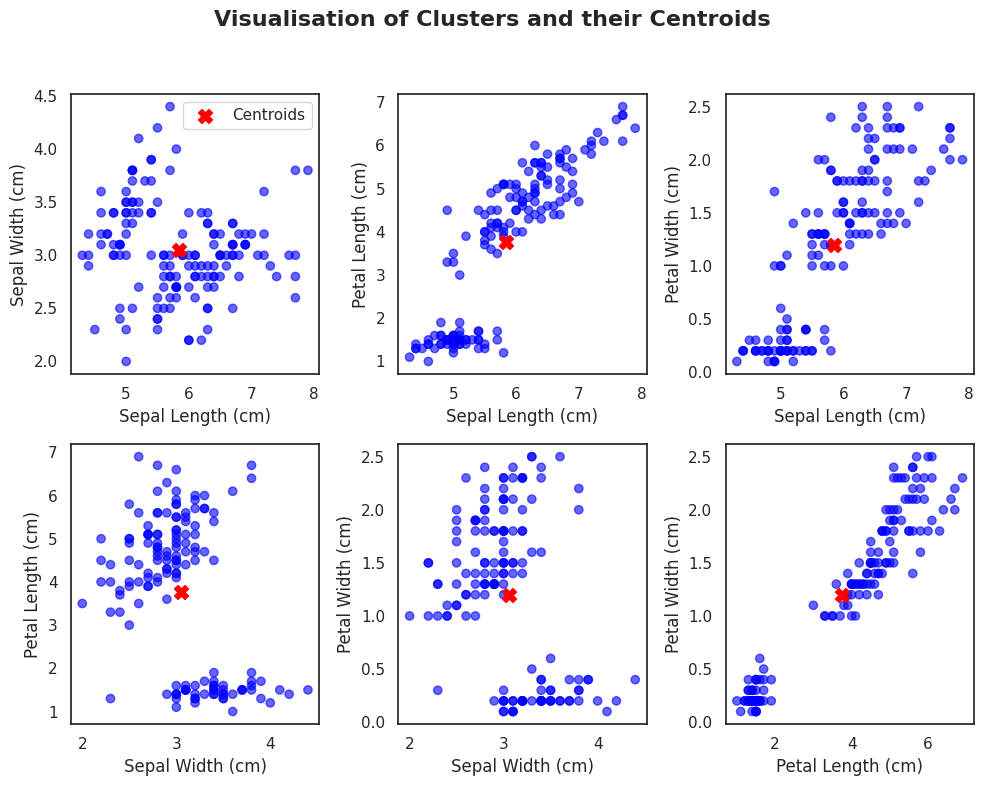

Original Means: [[5.84333333 3.054      3.75866667 1.19866667]]
Original variances: [[0.68112222 0.18675067 3.09242489 0.57853156]]
Means: [[5.89655553 3.03465837 3.95078532 1.26116817]]
Variances: [[0.72925227 0.16589442 2.86443003 0.43024192]]


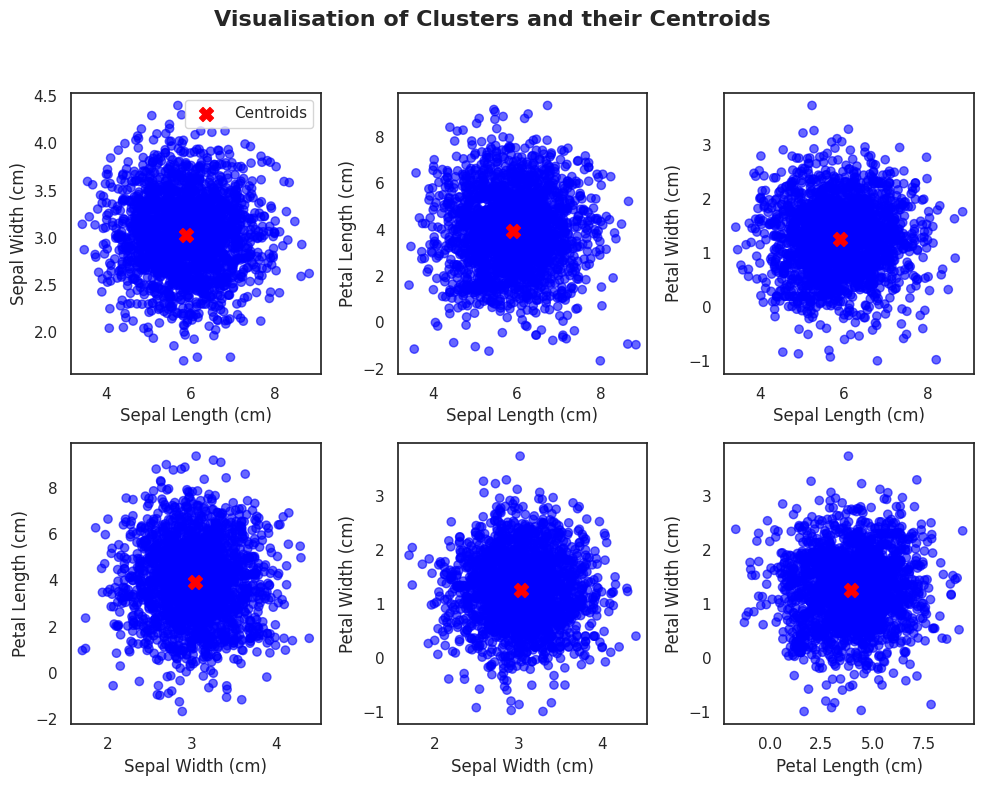

In [104]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture
n_clusters=1
M = 20  # points to be added as synthetic data
df = pd.read_csv('Iris.csv')

selected_columns = ['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']
data_matrix = df[selected_columns].to_numpy()

# Initial fit of Gaussian Mixtures
gmm = GaussianMixture(n_components=n_clusters, covariance_type='full', random_state=42)
gmm.fit(data_matrix)
cluster_assignments=gmm.predict(data_matrix)
orig_assignments=cluster_assignments.copy()
# Compute cluster means using the existing helper
centers = mean_clusters(data_matrix, cluster_assignments, n_clusters)
mean_first_ex=centers.copy()
plot_clusters(data_matrix, cluster_assignments, centers)

new_data = data_matrix.copy()
steps = 100  # Number of iterations
means = mean_clusters(data_matrix, cluster_assignments, n_clusters)
variances = variance_clusters(data_matrix, cluster_assignments, n_clusters)

print("Original Means:", means)
print("Original variances:", variances)
or_means=means.copy()
# Iteratively augment the dataset and re-cluster.
for i in range(steps):
    # Re-fit KMeans on the current dataset and obtain assignments
    gmm = GaussianMixture(n_components=n_clusters, covariance_type='full', random_state=42)
    gmm.fit(new_data)
    cluster_assignments=gmm.predict(new_data)
    # Recompute cluster statistics on the updated dataset
    means = mean_clusters(new_data, cluster_assignments, n_clusters)
    variances = variance_clusters(new_data, cluster_assignments, n_clusters)
    
    # Update dataset by adding synthetic points sampled from cluster distributions
    # Pass n_clusters as integer (3) to match update_dataset signature.
    new_data = update_dataset(new_data, cluster_assignments, M, n_clusters, random_state=42 + i)

# Final recomputation on the resulting dataset
gmm = GaussianMixture(n_components=n_clusters, covariance_type='full', random_state=42)
gmm.fit(new_data)
cluster_assignments=gmm.predict(new_data)
means_final = mean_clusters(new_data, cluster_assignments, n_clusters)
variances = variance_clusters(new_data, cluster_assignments, n_clusters)
mean_final_ex=means_final.copy()
print("Means:", means_final)
print("Variances:", variances)
plot_clusters(new_data, cluster_assignments, means_final)
cluster_assignments_original=cluster_assignments.copy()

In [105]:
# Displacements after CLL algorithm
delta=np.linalg.norm(means_final-or_means, axis=1)
print("delta: ",delta)
D=calculate_mean_inter_cluster_distance(or_means, distance_metric=euclidean_distance)
print("D: ",D)
Q=np.sum(delta/D)/n_clusters
print("Q: ", Q)

delta:  [0.20981591]
D:  [0.]
Q:  inf


/tmp/ipykernel_54630/221000834.py:6: RuntimeWarning: divide by zero encountered in divide
  Q=np.sum(delta/D)/n_clusters


In [106]:

Q = np.zeros(20)  

for n_clusters in range(2, 22):
    
    M = 20  # points to be added as synthetic data
    df = pd.read_csv('Iris.csv')

    selected_columns = ['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']
    data_matrix = df[selected_columns].to_numpy()

    # Initial fit of Gaussian Mixtures
    gmm = GaussianMixture(n_components=n_clusters, covariance_type='full', random_state=42)
    gmm.fit(data_matrix)
    cluster_assignments = gmm.predict(data_matrix)
    orig_assignments = cluster_assignments.copy()
    # Compute cluster means using the existing helper
    centers = mean_clusters(data_matrix, cluster_assignments, n_clusters)
    mean_first_ex = centers.copy()
    #plot_clusters(data_matrix, cluster_assignments, centers)

    new_data = data_matrix.copy()
    steps = 100  # Number of iterations
    means = mean_clusters(data_matrix, cluster_assignments, n_clusters)
    variances = variance_clusters(data_matrix, cluster_assignments, n_clusters)

    #print(f"n_clusters={n_clusters} - Original Means:\n", means)
    #print(f"n_clusters={n_clusters} - Original variances:\n", variances)
    or_means = means.copy()
    # Iteratively augment the dataset and re-cluster.
    for i in range(steps):
        gmm = GaussianMixture(n_components=n_clusters, covariance_type='full', random_state=42)
        gmm.fit(new_data)
        cluster_assignments = gmm.predict(new_data)
        means = mean_clusters(new_data, cluster_assignments, n_clusters)
        variances = variance_clusters(new_data, cluster_assignments, n_clusters)
        new_data = update_dataset(new_data, cluster_assignments, M, n_clusters, random_state=42 + i)

    # Final recomputation on the resulting dataset
    gmm = GaussianMixture(n_components=n_clusters, covariance_type='full', random_state=42)
    gmm.fit(new_data)
    cluster_assignments = gmm.predict(new_data)
    means_final = mean_clusters(new_data, cluster_assignments, n_clusters)
    variances = variance_clusters(new_data, cluster_assignments, n_clusters)
    mean_final_ex = means_final.copy()
    #print("Means:", means_final)
    #print("Variances:", variances)
    #plot_clusters(new_data, cluster_assignments, means_final)
    cluster_assignments_original = cluster_assignments.copy()
    delta = np.linalg.norm(means_final - or_means, axis=1)
    #print("delta: ", delta)
    D = calculate_mean_inter_cluster_distance(or_means, distance_metric=euclidean_distance)
    #print("D: ", D)

    # Avoid division by zero: replace zeros in D with nan and use nansum so we don't get inf
    safe_D = np.where(D == 0, np.nan, D)
    Q[n_clusters-2] = np.sum(delta / safe_D) / n_clusters

print(Q)

[0.01817297 0.0459851  0.20024653 0.62306084 1.01233464 0.65977682
 0.80209274 0.81718498 1.11379203 1.07374194 0.976927   0.72048297
 0.78852646 0.86950235 0.93363265 1.01736553 0.91357052 0.87757017
 0.88132704 0.94363061]


[ 2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21]


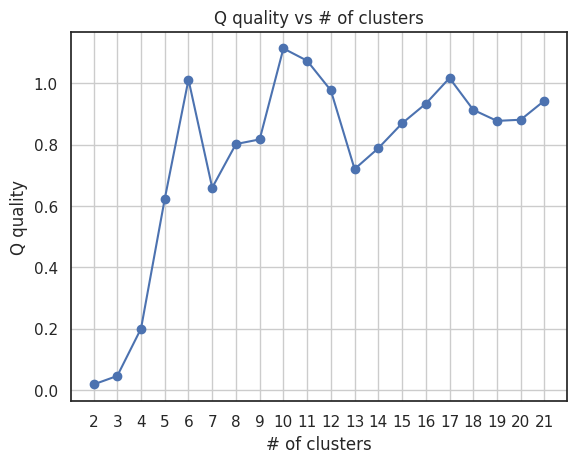

In [110]:
import numpy as np
import matplotlib.pyplot as plt

# Dati che hai definito:
n_clusters = np.arange(2, 22)  # Array [2, 3, ..., 21]
print(n_clusters)


# 1. Plot
plt.plot(n_clusters, Q, marker='o', linestyle='-')

# 2. **FORZATURA DEI TICK DELL'ASSE X**
# Imposta i tick dell'asse X esattamente sui valori contenuti nell'array n_clusters
plt.xticks(n_clusters)

# 3. Aggiunta di Elementi Essenziali
plt.title("Q quality vs # of clusters") # Titolo più appropriato
plt.xlabel("# of clusters")                
plt.ylabel("Q quality")                
plt.grid(True)                      

# 4. Mostra il Grafico
plt.show()